Run h=0.01: Baseline Established (First Run)

--- Results for Step Size h = 0.06 ---
Point-by-point errors vs first run: [0.      0.00477 0.00841 0.01114 0.0131  0.01445 0.01529 0.01574 0.01587
 0.01576 0.01545 0.01499 0.01443 0.01379 0.0131  0.01239 0.01166 0.01093
 0.01021 0.00951 0.00884 0.00819 0.00757 0.00698 0.00643 0.00591 0.00542
 0.00497 0.00455 0.00416 0.00379 0.00346 0.00315 0.00287]
Total Accumulated Error: 0.31727

--- Results for Step Size h = 0.11 ---
Point-by-point errors vs first run: [0.      0.01895 0.02992 0.03543 0.0373  0.03681 0.03487 0.03212 0.02899
 0.02575 0.0226  0.01963 0.01692 0.01448 0.01232 0.01042 0.00878 0.00737
 0.00617]
Total Accumulated Error: 0.39883

--- Results for Step Size h = 0.16 ---
Point-by-point errors vs first run: [0.      0.03415 0.04758 0.04974 0.04626 0.04033 0.03375 0.02748 0.02192
 0.01721 0.01335 0.01026 0.00781]
Total Accumulated Error: 0.34983

--- Results for Step Size h = 0.21 ---
Point-by-point errors vs first run: [0.      0.0

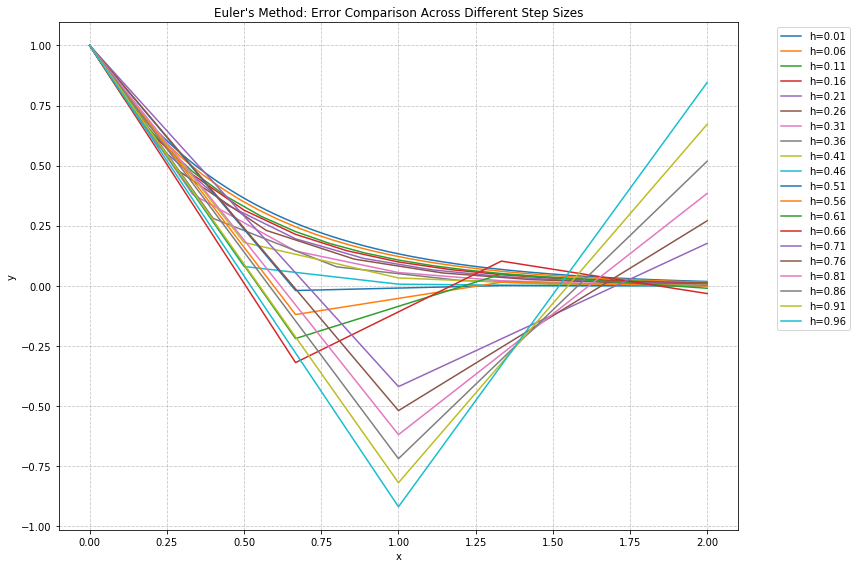

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define range for step size h
h_values = np.arange(0.01, 1.01, 0.05)
x_start, x_end = 0, 2

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y 

# store the first run for error comparison
baseline_x = None
baseline_y = None

plt.figure(figsize=(12, 8))

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    # np.linspace for x_end
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    
    # Initial condition: y(0) = 1
    y_vals[0] = 1
    
    # Euler's method
    for i in range(num_steps):
        y_vals[i + 1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    # Error Analysis
    if baseline_y is None:
        # First run (h=0.01) is the reference baseline
        baseline_x = x_vals
        baseline_y = y_vals
        print(f"Run h={h:.2f}: Baseline Established (First Run)")
    else:
        # Interpolate baseline to current x points to compare error at same locations
        ref_y_at_current_x = np.interp(x_vals, baseline_x, baseline_y)
        point_errors = np.abs(y_vals - ref_y_at_current_x)
        total_accumulated_error = np.sum(point_errors) 
        
        print(f"\n--- Results for Step Size h = {h:.2f} ---")
        print(f"Point-by-point errors vs first run: {np.round(point_errors, 5)}")
        print(f"Total Accumulated Error: {total_accumulated_error:.5f}")

    # Plot each step-size run
    plt.plot(x_vals, y_vals, label=f"h={h:.2f}")

# Formatting the plot
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method: Error Comparison Across Different Step Sizes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()